<a href="https://www.kaggle.com/code/sonawanelalitsunil/bmw-sales-dataset-ml-100?scriptVersionId=260181602" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bmw-sales-dataset/BMW sales data (2010-2024) (1).csv


## Title: BMW Sales Dataset

## Description:
The BMW Sales Dataset contains detailed records of BMW car sales, providing insights into sales performance, customer preferences, and market trends. It can include attributes such as model type, year of manufacture, sales volume, pricing, region of sale, and customer demographics. This dataset is useful for analyzing sales patterns, forecasting demand, evaluating the popularity of different models, and supporting business strategies in the automotive industry.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/bmw-sales-dataset/BMW sales data (2010-2024) (1).csv")

In [3]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [4]:
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [6]:
df.dtypes

Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
dtype: object

In [7]:
df.shape

(50000, 11)

In [8]:
df.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [11]:
df.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

## Data visualizations

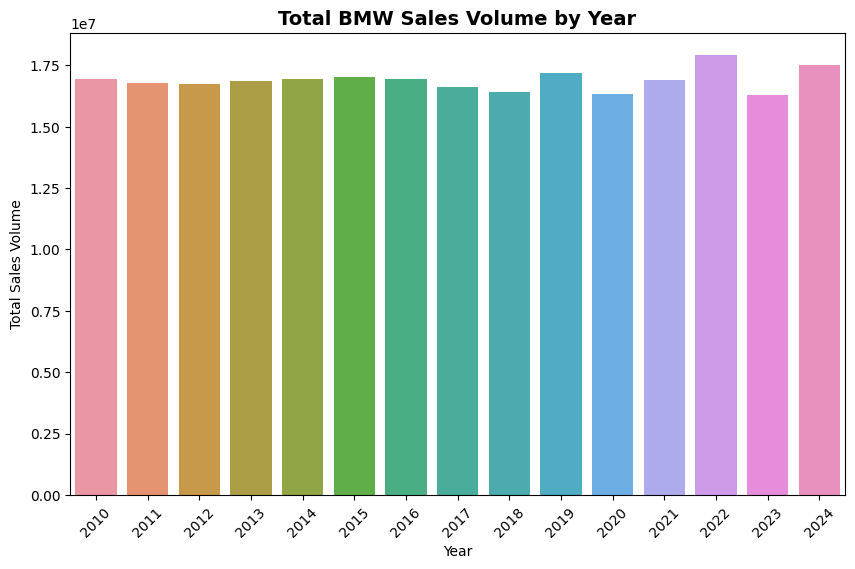

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Year", y="Sales_Volume", estimator="sum", ci=None)
plt.title("Total BMW Sales Volume by Year", fontsize=14, weight="bold")
plt.ylabel("Total Sales Volume")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.show()


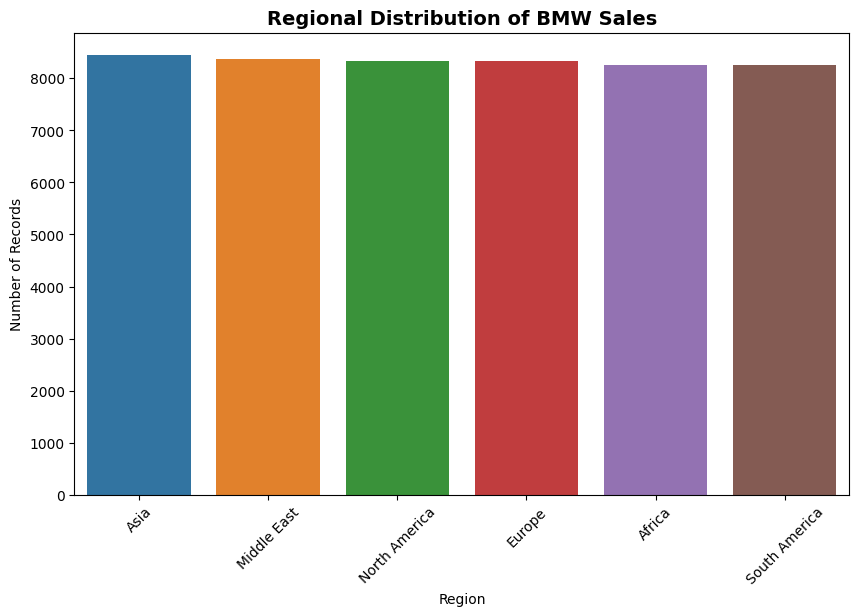

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Region", order=df["Region"].value_counts().index)
plt.title("Regional Distribution of BMW Sales", fontsize=14, weight="bold")
plt.ylabel("Number of Records")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.show()

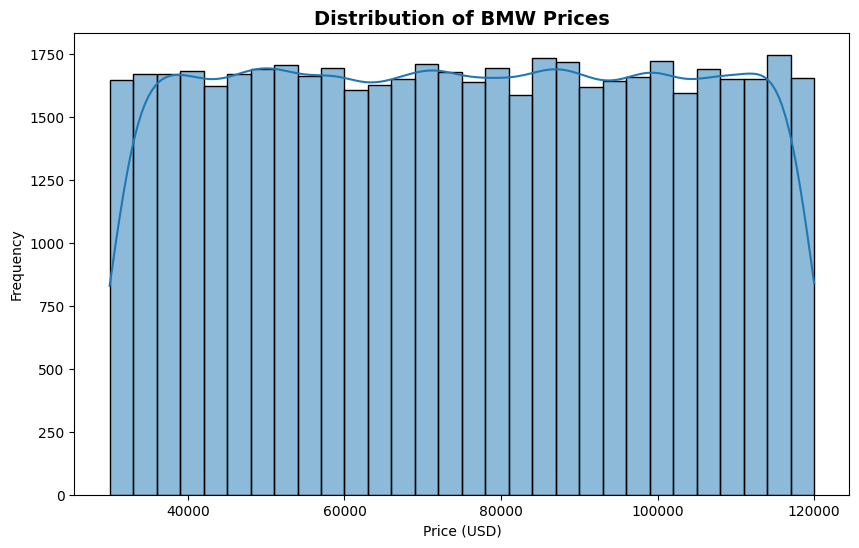

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df["Price_USD"], bins=30, kde=True)
plt.title("Distribution of BMW Prices", fontsize=14, weight="bold")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()


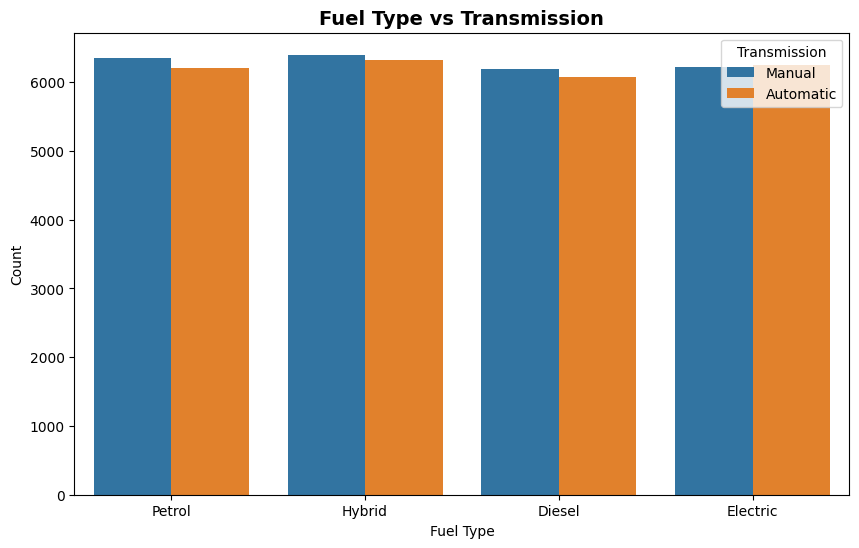

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Fuel_Type", hue="Transmission")
plt.title("Fuel Type vs Transmission", fontsize=14, weight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()


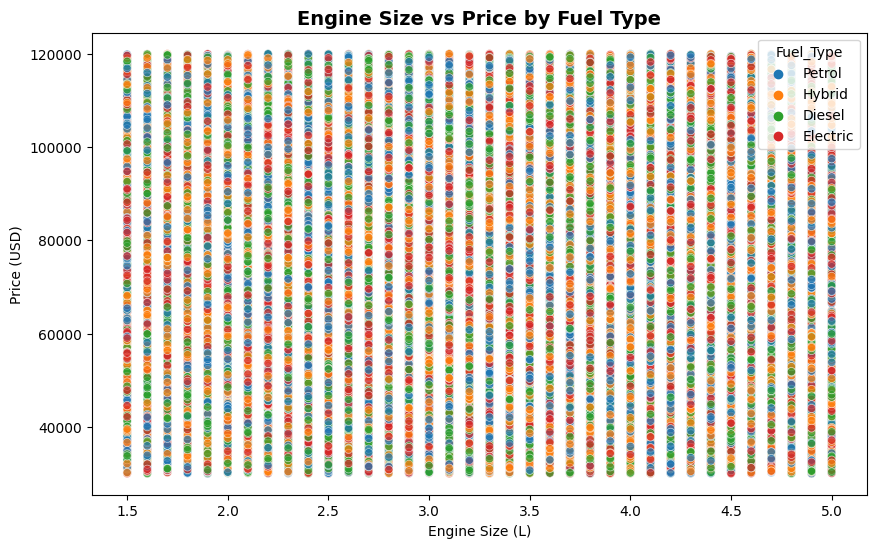

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Engine_Size_L", y="Price_USD", hue="Fuel_Type", alpha=0.7)
plt.title("Engine Size vs Price by Fuel Type", fontsize=14, weight="bold")
plt.xlabel("Engine Size (L)")
plt.ylabel("Price (USD)")
plt.show()


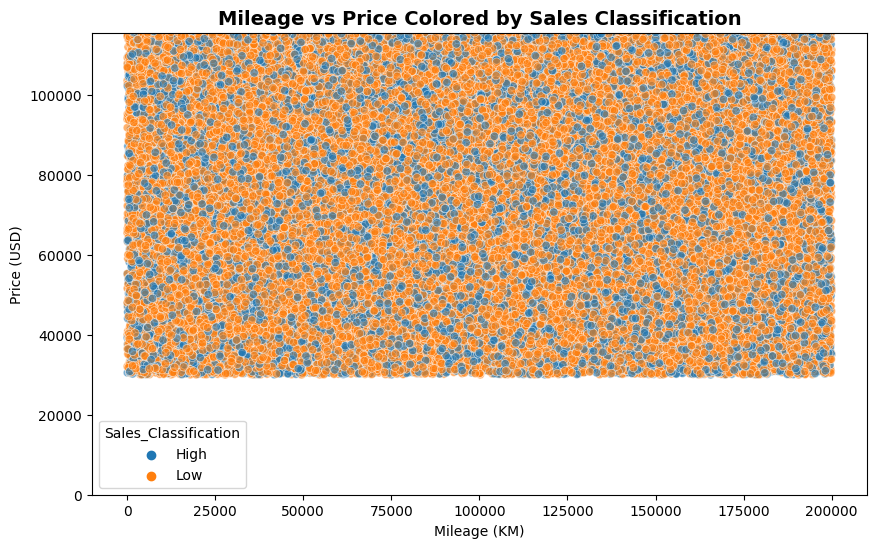

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Mileage_KM", y="Price_USD", hue="Sales_Classification", alpha=0.6)
plt.title("Mileage vs Price Colored by Sales Classification", fontsize=14, weight="bold")
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (USD)")
plt.ylim(0, df["Price_USD"].quantile(0.95))  # limit outliers
plt.show()


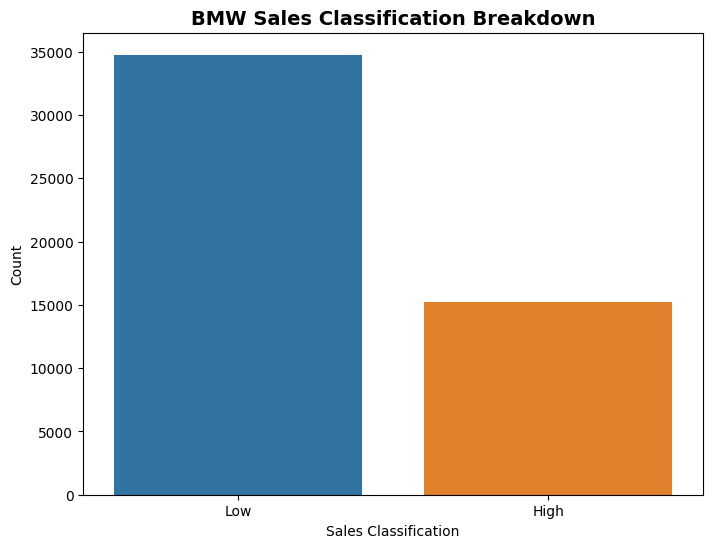

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Sales_Classification", order=df["Sales_Classification"].value_counts().index)
plt.title("BMW Sales Classification Breakdown", fontsize=14, weight="bold")
plt.ylabel("Count")
plt.xlabel("Sales Classification")
plt.show()


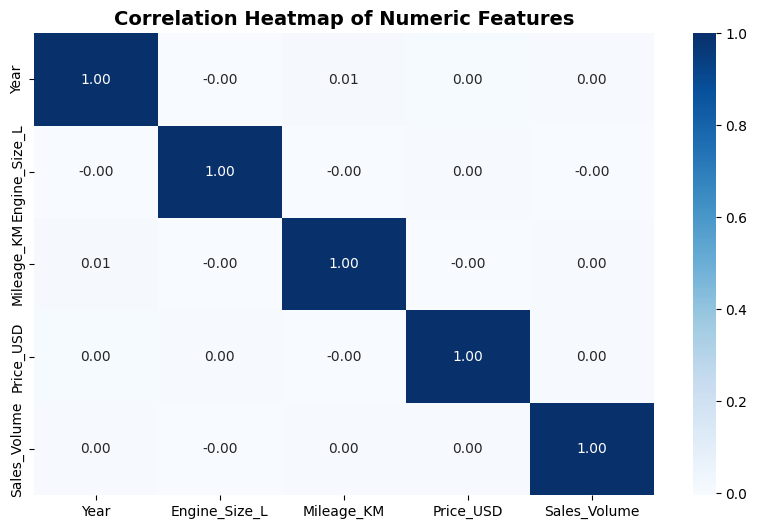

In [19]:
plt.figure(figsize=(10,6))
corr = df[["Year", "Engine_Size_L", "Mileage_KM", "Price_USD", "Sales_Volume"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, weight="bold")
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [21]:
categorical_cols = ["Model", "Region", "Color", "Fuel_Type", "Transmission"]
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [22]:
X = df.drop("Sales_Classification", axis=1)
y = df["Sales_Classification"]

In [23]:
if y.dtype == 'object' or y.dtype == 'category':
    y = encoder.fit_transform(y)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}

In [26]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append((name, acc))

In [27]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"])
print(results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True))

                 Model  Accuracy (%)
0        Decision Tree        100.00
1        Random Forest        100.00
2    Gradient Boosting        100.00
3             AdaBoost        100.00
4              XGBoost        100.00
5          Naive Bayes         99.91
6  Logistic Regression         99.84
7                  SVM         99.58
8                  KNN         95.97


## Thank you...pls upvote!!